# Install required library if running in a fresh Colab environment:


In [2]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)

In [3]:
sentences = [
    # Topic 1: Cricket (4 sentences)
    "The batsman hit a massive six over the long-on boundary.",
    "Fast bowlers rely on swing and pace to deceive the batsman.",
    "The fielding team executed a brilliant run out to win the match.",
    "The pitch is spinning aggressively, favoring the slow bowlers.",

    # Topic 2: Cooking (3 sentences)
    "Sauté the onions and garlic until they are golden brown.",
    "A pinch of salt and freshly ground black pepper enhances the flavor of the dish.",
    "Bake the cake in a preheated oven for forty-five minutes.",

    # Topic 3: Cybersecurity (3 sentences)
    "Implementing two-factor authentication significantly reduces the risk of unauthorized access.",
    "The firewall successfully blocked a massive distributed denial-of-service attack.",
    "Phishing emails trick users into revealing their sensitive passwords and credentials."
]

# 2. Generate embeddings using sentence-transformers

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# 3. Compute 10x10 cosine similarity matrix

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(embeddings)

# Display the matrix as a heatmap

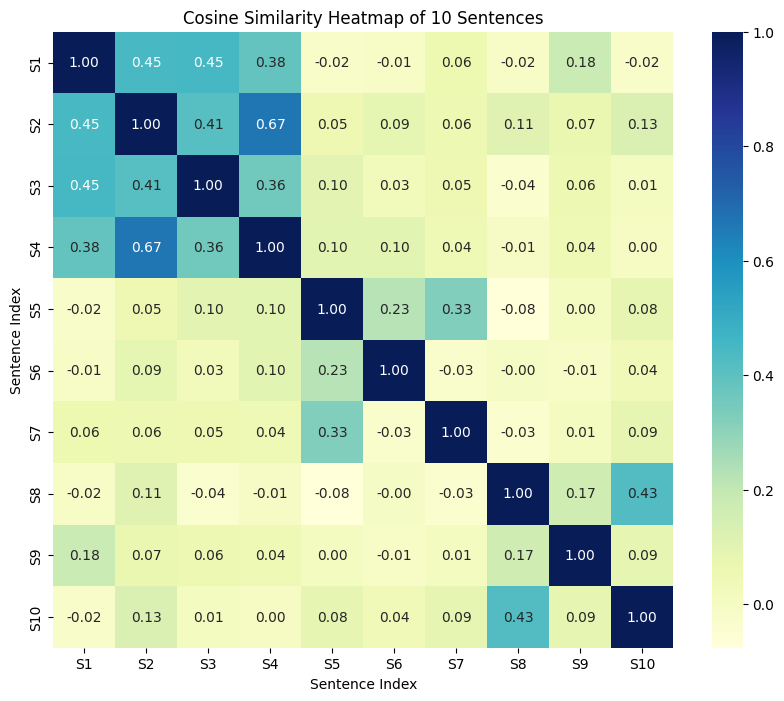

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu", fmt=".2f",
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("Cosine Similarity Heatmap of 10 Sentences")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()

# 4. Query sentence similarity

In [7]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 indices
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(sentences[idx])
    print("Similarity Score:", similarities[idx])
    print()

Query: The bowler took three wickets in one over

Top 2 similar sentences:

The batsman hit a massive six over the long-on boundary.
Similarity Score: 0.53192806

The pitch is spinning aggressively, favoring the slow bowlers.
Similarity Score: 0.5153921

